# General pipeline

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import logging

import numpy as np   
import pandas as pd
import geopandas as gpd
import xarray as xr

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.special import rel_entr          # KL divergence

logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
)
log = logging.getLogger("DistributionComparison")


# ─────────────────────────────────────────────────────────────────────────────
class DistributionComparisonPipeline:
    def __init__(
        self,
        era5_nc_path:   str,
        era5_var:       str,
        interp_nc_path: str,
        interp_var:     str,
        shapefile_path: str,
        interp_label:   str  = "Kriging (Best)",
        output_dir:     str  = "distribution_comparison",
        shapiro_limit:  int  = 5000,
    ):
        self.era5_nc_path   = era5_nc_path
        self.era5_var       = era5_var
        self.interp_nc_path = interp_nc_path
        self.interp_var     = interp_var
        self.shapefile_path = shapefile_path
        self.interp_label   = interp_label
        self.output_dir     = output_dir
        self.shapiro_limit  = shapiro_limit

        os.makedirs(output_dir, exist_ok=True)

        self.era5_vals   = None
        self.interp_vals = None

    def _clip_to_shapefile(self, ds: xr.Dataset, var: str) -> xr.Dataset:
        gdf = gpd.read_file(self.shapefile_path).to_crs("EPSG:4326")
        gdf_dissolved = gdf.dissolve()

        ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        ds = ds.rio.write_crs("EPSG:4326")

        ds_clipped = ds.rio.clip(
            gdf_dissolved.geometry,
            gdf_dissolved.crs,
            drop=False,
            all_touched=True,
        )
        return ds_clipped

    def load_data(self):
        ds_era5  = xr.open_dataset(self.era5_nc_path, chunks={"time": 30})
        era5_raw = ds_era5[self.era5_var].values.flatten()
        self.era5_vals = era5_raw[~np.isnan(era5_raw)]

        ds_interp = xr.open_dataset(self.interp_nc_path, chunks={"time": 30})
        ds_interp_clipped = self._clip_to_shapefile(ds_interp, self.interp_var)

        clipped_path = os.path.join(
            self.output_dir,
            f"interp_clipped_{self.interp_var}.nc"
        )
        ds_interp_clipped.to_netcdf(clipped_path)

        interp_raw = ds_interp_clipped[self.interp_var].values.flatten()
        self.interp_vals = interp_raw[~np.isnan(interp_raw)]

    def _compute_stats(self) -> pd.DataFrame:
        e = self.era5_vals
        s = self.interp_vals

        ks_stat, ks_p = stats.ks_2samp(e, s)

        combined_min = min(e.min(), s.min())
        combined_max = max(e.max(), s.max())
        bins   = np.linspace(combined_min, combined_max, 200)
        p, _   = np.histogram(e, bins=bins, density=True)
        q, _   = np.histogram(s, bins=bins, density=True)
        p      = p + 1e-10
        q      = q + 1e-10
        kl_div = float(np.sum(rel_entr(p, q)))

        rows = [
            ("Central Tendency", "Mean", np.mean(e), np.mean(s)),
            ("Central Tendency", "Median", np.median(e), np.median(s)),
            ("Dispersion", "Std Deviation", np.std(e), np.std(s)),
            ("Dispersion", "Variance", np.var(e), np.var(s)),
            ("Dispersion", "Min", np.min(e), np.min(s)),
            ("Dispersion", "Max", np.max(e), np.max(s)),
            ("Dispersion", "Range", np.ptp(e), np.ptp(s)),
            ("Dispersion", "IQR",
             float(np.percentile(e, 75) - np.percentile(e, 25)),
             float(np.percentile(s, 75) - np.percentile(s, 25))),
            ("Distribution", "Skewness", stats.skew(e), stats.skew(s)),
            ("Distribution", "Kurtosis", stats.kurtosis(e), stats.kurtosis(s)), 
            ("Distribution", "KS-test statistic", float(ks_stat), float(ks_stat)),
            ("Distribution", "KS-test p-value", float(ks_p), float(ks_p)),
            ("Distribution", "KL Divergence", float(kl_div), float(kl_div)),
        ]

        df = pd.DataFrame(rows, columns=["Pillar", "Metric", "ERA5", self.interp_label])
        df["ERA5"]            = df["ERA5"].round(6)
        df[self.interp_label] = df[self.interp_label].round(6)
        return df

    def _plot(self, stats_df: pd.DataFrame):
        e     = self.era5_vals
        s     = self.interp_vals
        label = self.interp_label

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        ax = axes[0]
        bp = ax.boxplot(
            [e, s],
            labels=["ERA5", label],
            patch_artist=True,
            medianprops=dict(color="black", linewidth=2),
        )
        bp["boxes"][0].set_facecolor("#4C9BE8")
        bp["boxes"][1].set_facecolor("#E8834C")
        ax.set_title("Central Tendency & Dispersion (Boxplot)", fontsize=11)
        ax.set_ylabel("Value", fontsize=10)
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        sns.kdeplot(e, ax=ax, label="ERA5", fill=True, color="#4C9BE8", alpha=0.55, linewidth=1.5)
        sns.kdeplot(s, ax=ax, label=label, fill=True, color="#E8834C", alpha=0.55, linewidth=1.5)
        ax.axvline(np.mean(e), color="#4C9BE8", linestyle="--", linewidth=1.2, label=f"ERA5 mean={np.mean(e):.2f}")
        ax.axvline(np.mean(s), color="#E8834C", linestyle="--", linewidth=1.2, label=f"{label} mean={np.mean(s):.2f}")
        ax.set_title("Distribution Shape (KDE)", fontsize=11)
        ax.set_xlabel("Value", fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = axes[2]
        sns.ecdfplot(e, ax=ax, label="ERA5", color="#4C9BE8", linewidth=2)
        sns.ecdfplot(s, ax=ax, label=label, color="#E8834C", linewidth=2)
        ax.set_title("Cumulative Distribution (CDF)", fontsize=11)
        ax.set_xlabel("Value", fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3)

        row_ks  = stats_df[stats_df["Metric"] == "KS-test p-value"].iloc[0]
        row_kl  = stats_df[stats_df["Metric"] == "KL Divergence"].iloc[0]
        row_skw = stats_df[stats_df["Metric"] == "Skewness"].iloc[0]
        
        txt = (
            f"KS p-value={row_ks['ERA5']} | "
            f"KL Divergence={row_kl['ERA5']} | "
            f"Skewness ERA5={row_skw['ERA5']} vs {label}={row_skw[self.interp_label]}"
        )
        fig.text(0.5, -0.03, txt, ha="center", fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray"))
        plt.suptitle(f"ERA5 vs {label} | Distribution Similarity Analysis", fontsize=13, y=1.02)
        plt.tight_layout()

        path = os.path.join(self.output_dir, "distribution_comparison.png")
        plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

    def run(self) -> pd.DataFrame:
        self.load_data()
        stats_df = self._compute_stats()
        csv_path = os.path.join(self.output_dir, "distribution_stats.csv")
        stats_df.to_csv(csv_path, index=False)
        self._plot(stats_df)
        return stats_df

# Temperature

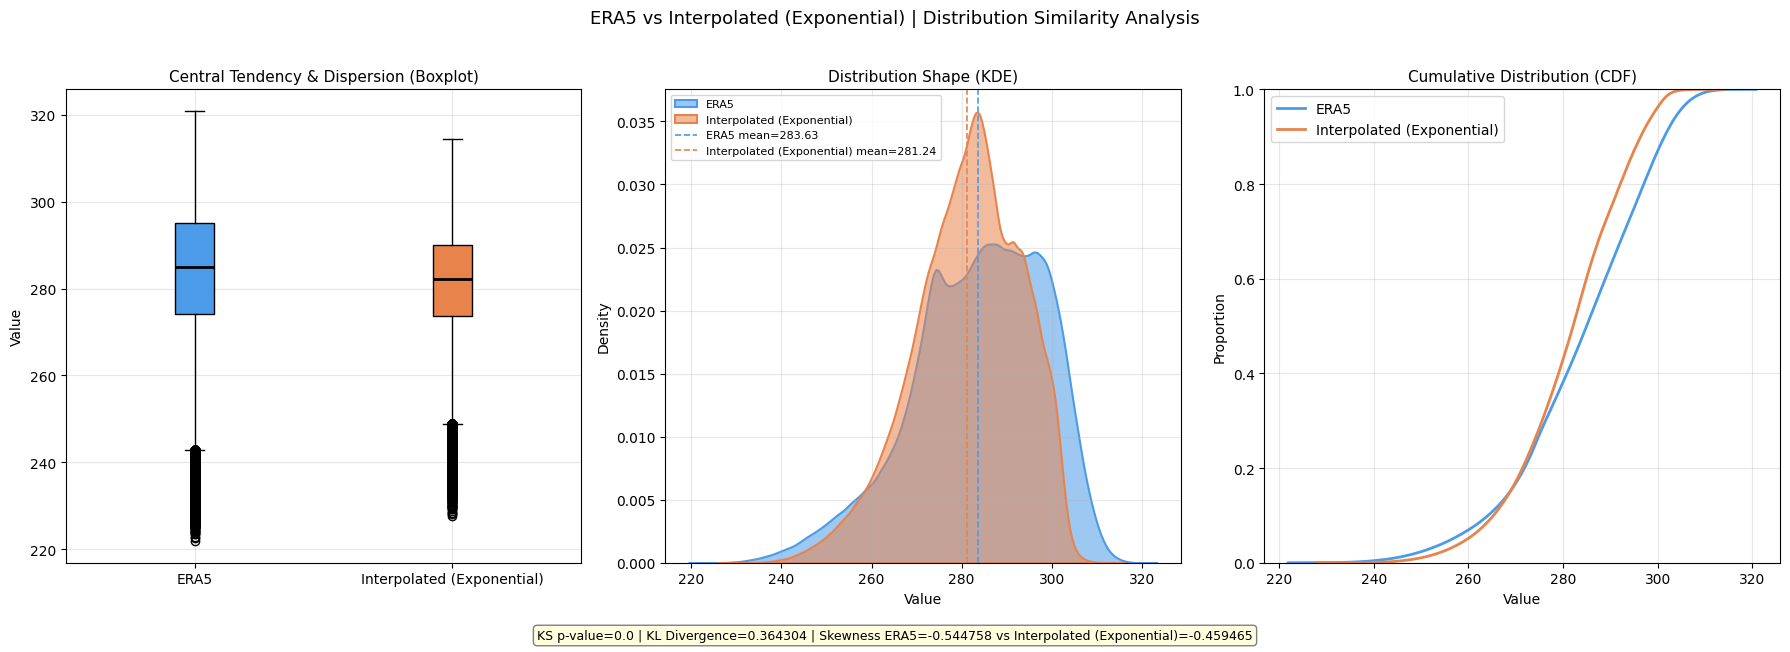

,Pillar,Metric,ERA5,Interpolated (Exponential)
0,Central Tendency,Mean,283.631805,281.240841
1,Central Tendency,Median,284.994308,282.135425
2,Dispersion,Std Deviation,14.616000,11.927433
3,Dispersion,Variance,213.627448,142.263669
4,Dispersion,Min,221.844925,227.694934
5,Dispersion,Max,320.912842,314.320782
6,Dispersion,Range,99.067917,86.625848
7,Dispersion,IQR,20.914925,16.528329
8,Distribution,Skewness,-0.544758,-0.459465
9,Distribution,Kurtosis,-0.004645,-0.030521


In [3]:
pipe = DistributionComparisonPipeline(
    era5_nc_path   = r"era5_temperature\era5_clipped.nc",
    era5_var       = "t2m",
    interp_nc_path = r"temperature_interpolated_results\interpolated_kriging_exponential.nc",
    interp_var     = "AirTemperature",
    shapefile_path = r"usa shape file\cb_2022_us_bg_500k.shp",
    interp_label   = "Interpolated (Exponential)",
    output_dir     = r"distribution_comparison\temp",
)
pipe.run()

# Soil Moisture

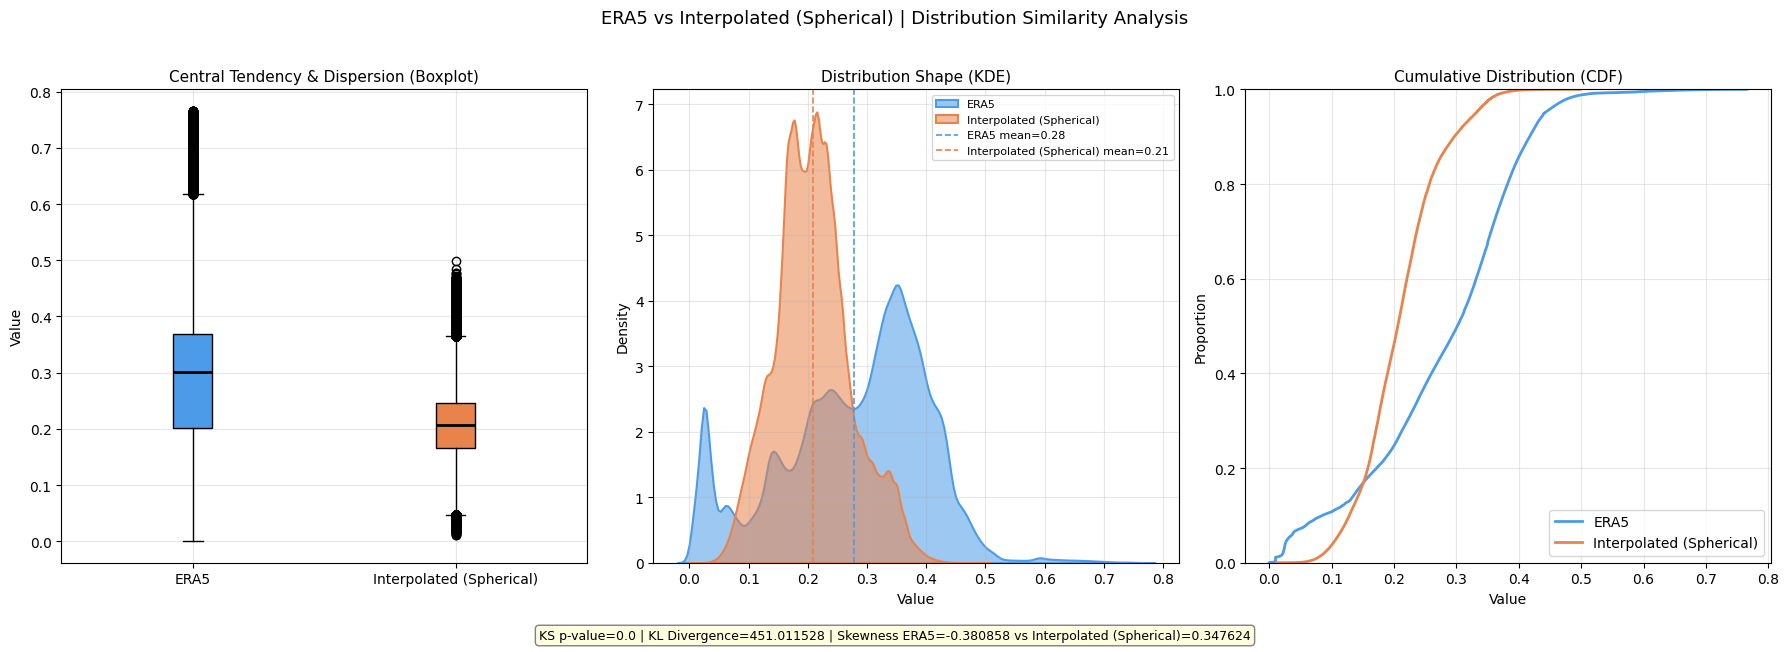

,Pillar,Metric,ERA5,Interpolated (Spherical)
0,Central Tendency,Mean,0.278373,0.208946
1,Central Tendency,Median,0.301483,0.205979
2,Dispersion,Std Deviation,0.123203,0.063955
3,Dispersion,Variance,0.015179,0.004090
4,Dispersion,Min,-0.000000,0.010786
5,Dispersion,Max,0.766006,0.498990
6,Dispersion,Range,0.766006,0.488204
7,Dispersion,IQR,0.166901,0.079267
8,Distribution,Skewness,-0.380858,0.347624
9,Distribution,Kurtosis,-0.218402,0.064681


In [4]:
pipe = DistributionComparisonPipeline(
    era5_nc_path   = r"era5_soil_moisture\era5_clipped.nc",
    era5_var       = "swvl1",
    interp_nc_path = r"SoilMoist_interpolated_results\interpolated_kriging_spherical.nc",
    interp_var     = "SoilMoisture10cm",
    shapefile_path = r"usa shape file\cb_2022_us_bg_500k.shp",
    interp_label   = "Interpolated (Spherical)",
    output_dir     = r"distribution_comparison\soil_moist",
)
pipe.run()

# Soil Temperature

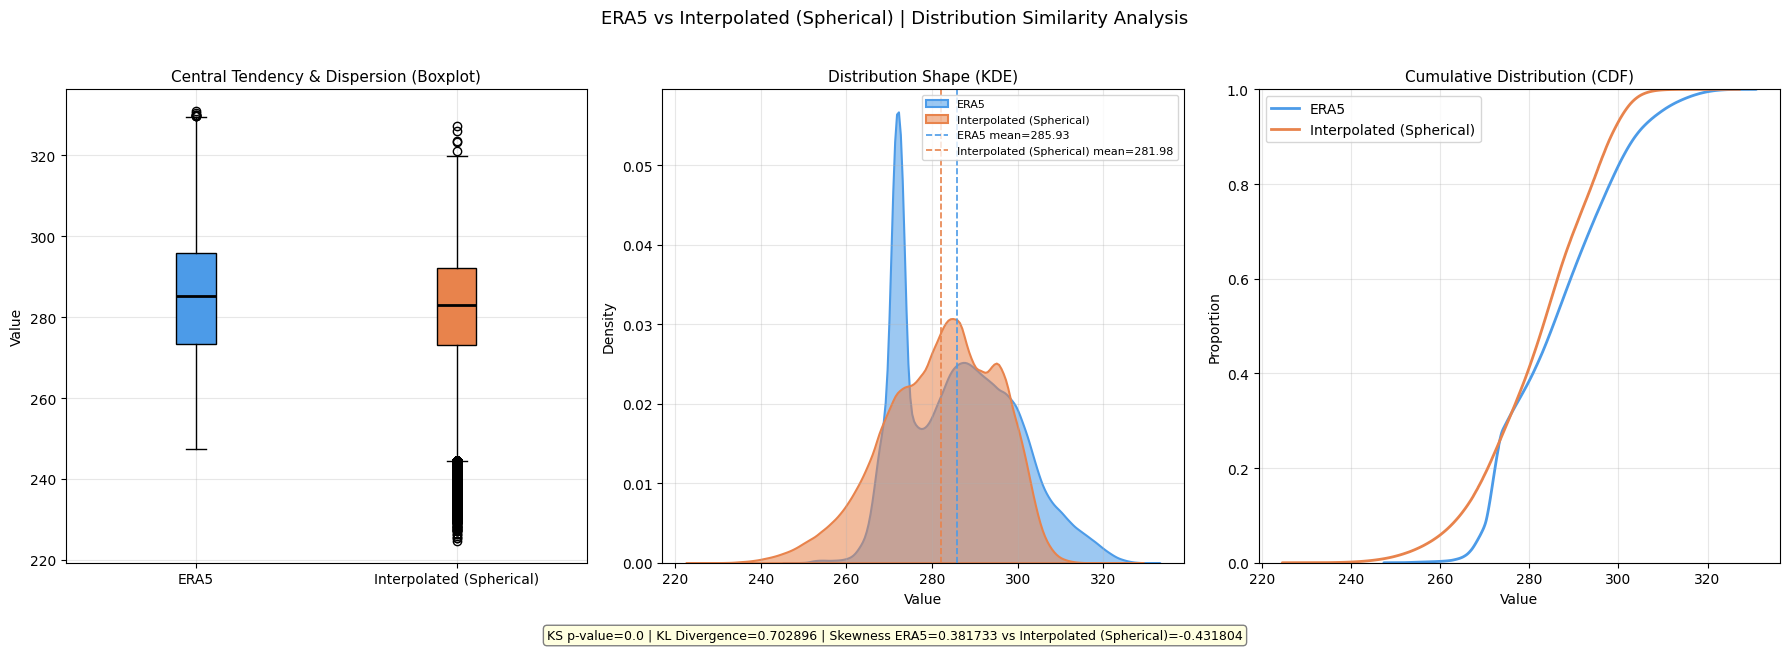

,Pillar,Metric,ERA5,Interpolated (Spherical)
0,Central Tendency,Mean,285.930453,281.975657
1,Central Tendency,Median,285.311798,283.092197
2,Dispersion,Std Deviation,13.230045,13.090740
3,Dispersion,Variance,175.034100,171.367479
4,Dispersion,Min,247.416489,224.624723
5,Dispersion,Max,330.935791,327.250258
6,Dispersion,Range,83.519302,102.625534
7,Dispersion,IQR,22.531471,19.016425
8,Distribution,Skewness,0.381733,-0.431804
9,Distribution,Kurtosis,-0.644525,-0.172100


In [5]:
pipe = DistributionComparisonPipeline(
    era5_nc_path   = r"era5_soil_temperature\era5_clipped.nc",
    era5_var       = "stl1",
    interp_nc_path = r"SoilTemp_interpolated_results\interpolated_kriging_spherical.nc",
    interp_var     = "SoilTemperature",
    shapefile_path = r"usa shape file\cb_2022_us_bg_500k.shp",
    interp_label   = "Interpolated (Spherical)",
    output_dir     = r"distribution_comparison\soil_temp",
)
pipe.run()

# Rainfall (ppt.)

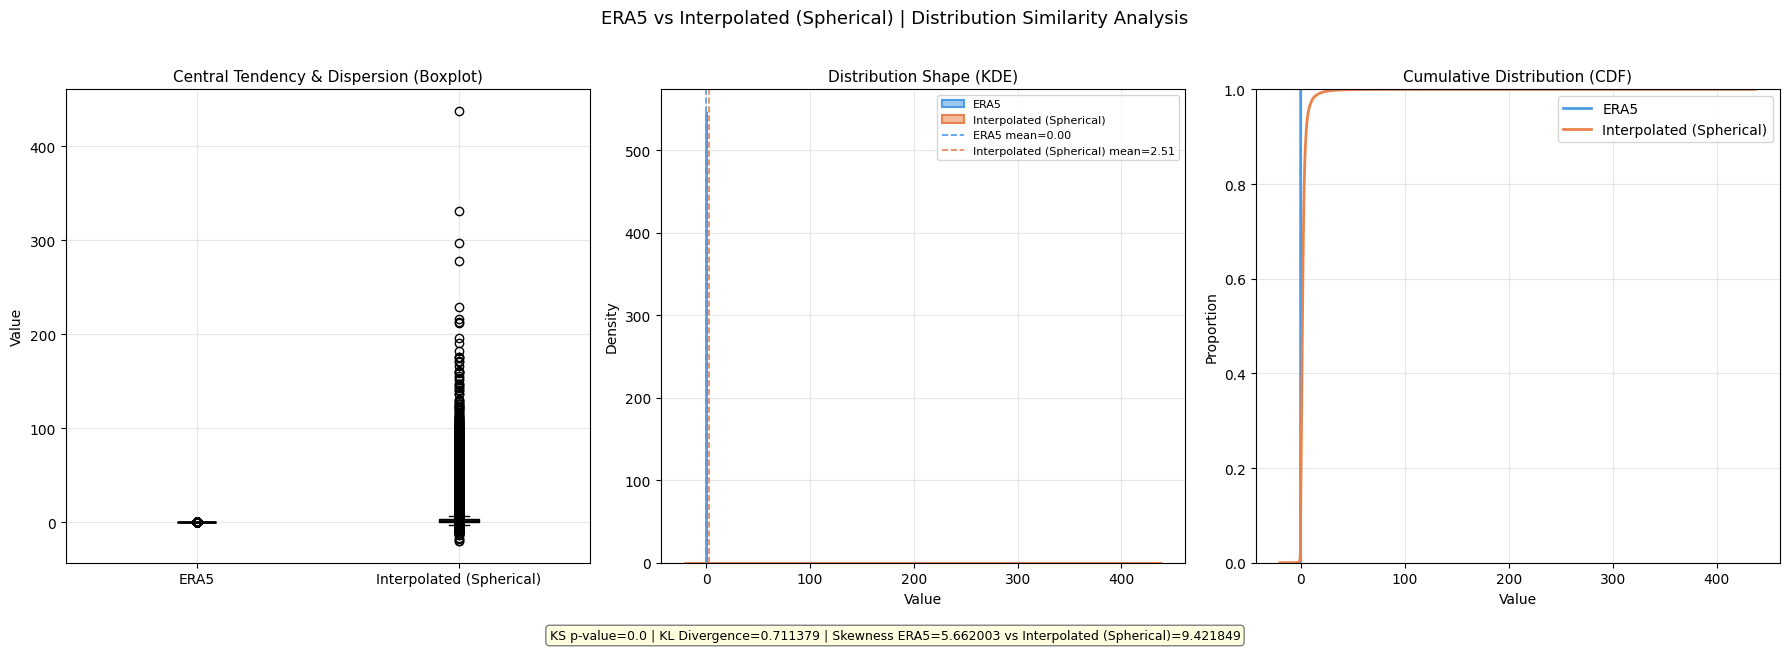

,Pillar,Metric,ERA5,Interpolated (Spherical)
0,Central Tendency,Mean,0.002226,2.508531
1,Central Tendency,Median,0.000148,1.770833
2,Dispersion,Std Deviation,0.005611,3.735277
3,Dispersion,Variance,0.000031,13.952297
4,Dispersion,Min,-0.000000,-20.251563
5,Dispersion,Max,0.256825,437.726837
6,Dispersion,Range,0.256825,457.978400
7,Dispersion,IQR,0.001676,2.404471
8,Distribution,Skewness,5.662003,9.421849
9,Distribution,Kurtosis,56.112685,286.994459


In [11]:
pipe = DistributionComparisonPipeline(
    era5_nc_path   = r"era5_total_ppt\era5_clipped.nc",
    era5_var       = "tp",
    interp_nc_path = r"Precipitation_interpolated_results\interpolated_kriging_spherical.nc",
    interp_var     = "Precipitation",
    shapefile_path = r"usa shape file\cb_2022_us_bg_500k.shp",
    interp_label   = "Interpolated (Spherical)",
    output_dir     = r"distribution_comparison\rainfall",
)
pipe.run()

# Relative Humidity

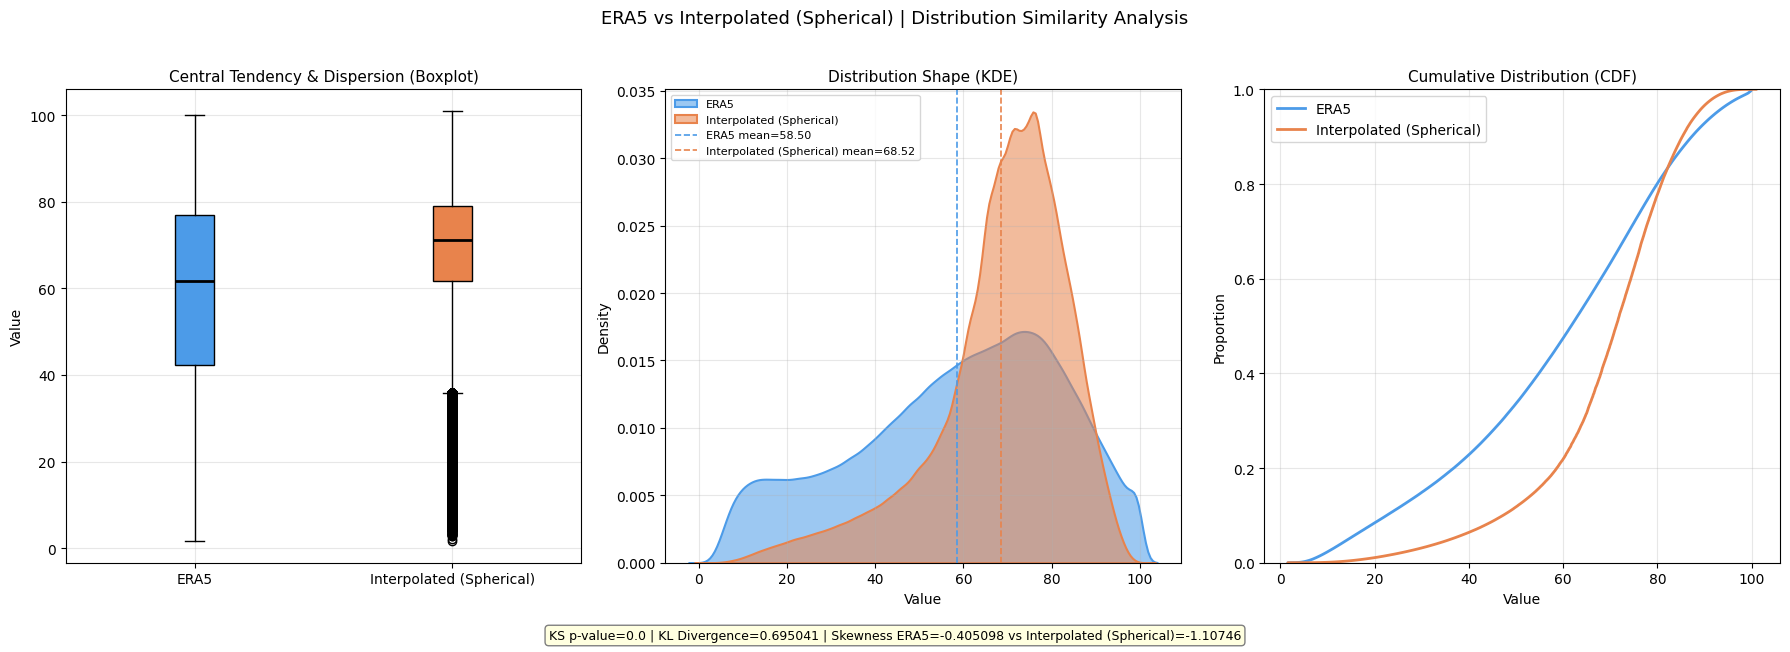

,Pillar,Metric,ERA5,Interpolated (Spherical)
0,Central Tendency,Mean,58.495264,68.519511
1,Central Tendency,Median,61.686087,71.239850
2,Dispersion,Std Deviation,23.491628,15.454493
3,Dispersion,Variance,551.856604,238.841368
4,Dispersion,Min,1.590714,1.584492
5,Dispersion,Max,100.000000,101.039118
6,Dispersion,Range,98.409286,99.454626
7,Dispersion,IQR,34.591969,17.263281
8,Distribution,Skewness,-0.405098,-1.107460
9,Distribution,Kurtosis,-0.699524,1.376310


In [12]:
pipe = DistributionComparisonPipeline(
    era5_nc_path   = r"era5_dewtemperature\era5_relative_humidity.nc",
    era5_var       = "relative_humidity",
    interp_nc_path = r"relativehumidity_interpolated_results\interpolated_kriging_exponential.nc",
    interp_var     = "RelativeHumidity",
    shapefile_path = r"usa shape file\cb_2022_us_bg_500k.shp",
    interp_label   = "Interpolated (Spherical)",
    output_dir     = r"distribution_comparison\Relative_Humidity",
)
pipe.run()